In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [26]:
df=pd.read_csv("Advertising.csv")
df.head(4)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5


In [27]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [28]:
df.info() # no null, no object datatype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [29]:
#sns.pairplot(df)
# linearity not present

<Axes: >

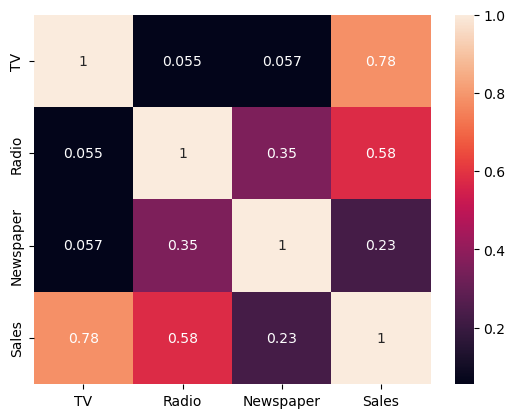

In [30]:
# multicollinearity
sns.heatmap(df.corr(),annot=True)
# failed

In [31]:
features=df.drop("Sales",axis=1)
target=df["Sales"]

In [32]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(features,target,
                                           random_state=2,
                                           test_size=0.2)

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [34]:
from sklearn.metrics import mean_squared_error,r2_score
for i in range(2,8):
    model=Pipeline(
        [
            ("poly",PolynomialFeatures(degree=i)),
            ("scaler",StandardScaler()),
            ("lr",LinearRegression())
        ]
       )
    model.fit(xtrain,ytrain)
    ypred=model.predict(xtest)
    mse=mean_squared_error(ytest,ypred)
    r2=r2_score(ytest,ypred)
    print(f"degree{i} : mse: {mse} r2:{r2}")

degree2 : mse: 0.30810130776368555 r2:0.9834144084890476
degree3 : mse: 0.18853344064016744 r2:0.9898509400842577
degree4 : mse: 0.36992736719055314 r2:0.9800862117545748
degree5 : mse: 12.155690966470038 r2:0.34563950290700607
degree6 : mse: 115.31636670203795 r2:-5.207666454029338
degree7 : mse: 8190.732322273235 r2:-439.92036304167397


In [35]:
model=Pipeline(
        [
            ("poly",PolynomialFeatures(degree=3)),
            ("scaler",StandardScaler()),
            ("lr",LinearRegression())
        ]
       )
model.fit(xtrain,ytrain)
ypred=model.predict(xtest)
mse=mean_squared_error(ytest,ypred)
r2=r2_score(ytest,ypred)
print(f"degree{i} : mse: {mse} r2:{r2}")

degree7 : mse: 0.18853344064016744 r2:0.9898509400842577


In [36]:
print("Training Score : ",model.score(xtrain,ytrain))
print("Testing Score : ",model.score(xtest,ytest))

Training Score :  0.9920288935246148
Testing Score :  0.9898509400842577


In [42]:
from sklearn.linear_model import Ridge,Lasso
r=Pipeline(
        [
            ("poly",PolynomialFeatures(degree=3)),
            ("scaler",StandardScaler()),
            ("r",Ridge(alpha=1)) # L2 - 0.01, 0.1,1,10
        ]
       )
r.fit(xtrain,ytrain)
ypred=r.predict(xtest)
mse=mean_squared_error(ytest,ypred)
r2=r2_score(ytest,ypred)
print(f"degree{i} : mse: {mse} r2:{r2}")
print("Training Score : ",r.score(xtrain,ytrain))
print("Testing Score : ",r.score(xtest,ytest))

degree7 : mse: 0.34390037240484117 r2:0.9814872869622938
Training Score :  0.9852219542348234
Testing Score :  0.9814872869622938


In [50]:
la=Pipeline(
        [
            ("poly",PolynomialFeatures(degree=3)),
            ("scaler",StandardScaler()),
            ("la",Lasso(alpha=0.02)) # L2 - 0.01, 0.1,1,10
        ]
       )
la.fit(xtrain,ytrain)
ypred=la.predict(xtest)
mse=mean_squared_error(ytest,ypred)
r2=r2_score(ytest,ypred)
print(f"degree{i} : mse: {mse} r2:{r2}")
print("Training Score : ",la.score(xtrain,ytrain))
print("Testing Score : ",la.score(xtest,ytest))

degree7 : mse: 0.3031692654167548 r2:0.9836799083023221
Training Score :  0.9858069070304835
Testing Score :  0.9836799083023221


In [60]:
coef_lr=model.named_steps["lr"].coef_
intercept_lr=model.named_steps["lr"].intercept_
#feature_names_lr=model.named_steps["poly"].get_feature_names_out()

coef_r=r.named_steps["r"].coef_
intercept_r=r.named_steps["r"].intercept_
#feature_names_r=r.named_steps["poly"].get_feature_names_out()

coef_la=la.named_steps["la"].coef_
intercept_la=la.named_steps["la"].intercept_
#feature_names_la=la.named_steps["poly"].get_feature_names_out()

In [69]:
print(f"coef_lr : {coef_lr} \ncoef_r : {coef_r} \ncoef_la:{coef_la}")

coef_lr : [  0.           7.62144554   0.5838447    0.33651271 -11.32650464
   4.8820594   -0.78951062  -0.37481916  -0.6473441    0.19987747
   5.62785138  -1.41291536   0.81606278   0.37063306  -0.11059307
  -0.15971105   0.02594055   0.29541102   0.40175303  -0.29676464] 
coef_r : [ 0.          3.7158308   0.66817357  0.12859692 -1.4806229   2.9363387
  0.10202197 -0.16093703  0.07654853 -0.3338559  -0.29211667 -0.22104379
 -0.55147315  0.81772721  0.17411199  0.26866285 -0.16928669  0.01399642
  0.07866676  0.07626725] 
coef_la:[ 0.          3.86264464  0.36218188  0.         -2.28470195  3.75749604
 -0.          0.          0.          0.         -0.         -0.
 -0.02771456  0.          0.          0.          0.          0.11312364
  0.          0.        ]


In [63]:
len(feature_names_la)

20

In [ ]:
#Cross validation

In [71]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,features,target,cv=5) # linear regression
print(scores)
print(np.mean(scores))

[0.99245183 0.99232209 0.99041622 0.97276116 0.99485021]
0.9885603012562996


In [72]:
scores=cross_val_score(r,features,target,cv=5) # ridge or l2
print(scores)
print(np.mean(scores))

[0.9876824  0.98800452 0.99081025 0.94590569 0.99484191]
0.981448956373483


In [73]:
scores=cross_val_score(la,features,target,cv=5) # lasso or l1
print(scores)
print(np.mean(scores))

[0.98845147 0.98907711 0.99061577 0.94833753 0.99617567]
0.9825315095478935
